In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('../src')
from preprocessing import DatasetPreprocessor

In [2]:
df = pd.read_excel('../data/raw/classicMLCourseWorkData.xlsx')

In [3]:
df.shape

(1001, 214)

In [4]:
df.dtypes

Unnamed: 0             int64
IC50, mM             float64
CC50, mM             float64
SI                   float64
MaxAbsEStateIndex    float64
                      ...   
fr_thiazole            int64
fr_thiocyan            int64
fr_thiophene           int64
fr_unbrch_alkane       int64
fr_urea                int64
Length: 214, dtype: object

In [5]:
# Проверим на наличие дубликатов
df.duplicated().sum()

np.int64(0)

In [6]:
df['Unnamed: 0'].unique()

array([   0,    1,    2, ...,  998,  999, 1000], shape=(1001,))

'Unnamed: 0' - это индекс из Excel. Удалить

#### Исследование целевых признаков

In [7]:
df[['IC50, mM', 'CC50, mM', 'SI']].describe()

,"IC50, mM","CC50, mM",SI
count,1001.000000,1001.000000,1001.000000
mean,222.805156,589.110728,72.508823
std,402.169734,642.867508,684.482739
min,0.003517,0.700808,0.011489
25%,12.515396,99.999036,1.433333
50%,46.585183,411.039342,3.846154
75%,224.975928,894.089176,16.566667
max,4128.529377,4538.976189,15620.600000


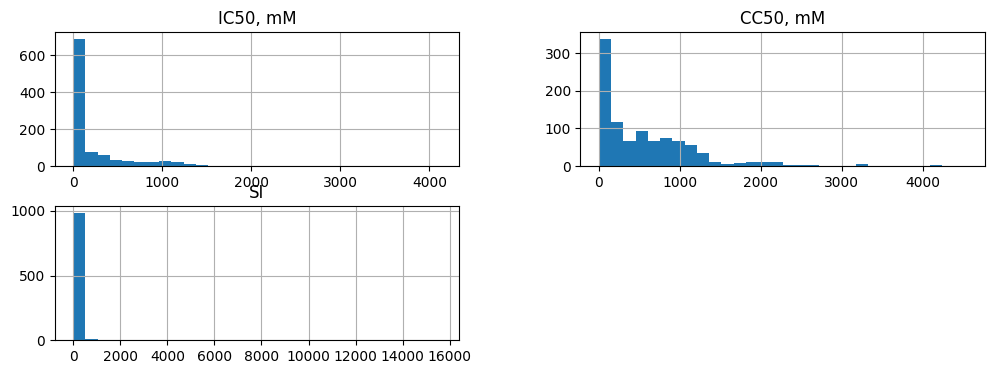

In [8]:
plt.style.use('default')
df[['IC50, mM', 'CC50, mM', 'SI']].hist(bins=30, figsize=(12, 4))
plt.show()

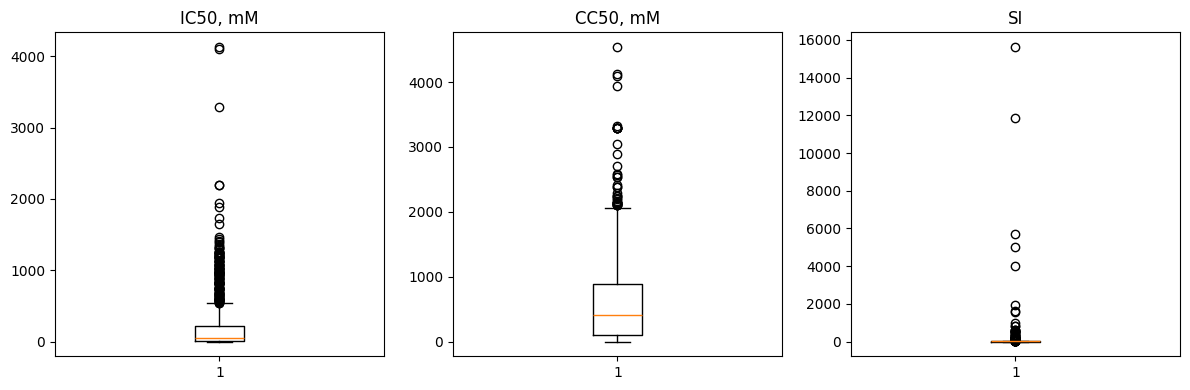

In [9]:
plt.figure(figsize=(12, 4))

for i, col in enumerate(['IC50, mM', 'CC50, mM', 'SI'], 1):
    plt.subplot(1, 3, i)
    plt.boxplot(df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Целевые признаки имеют правостороннюю асимметрию
Присутствуют значительные выбросы

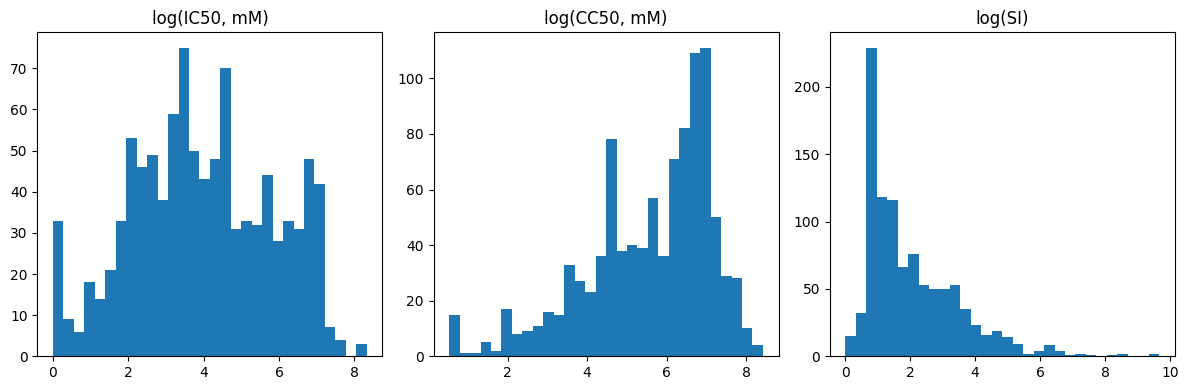

In [10]:
# Проверим лог-преобразование
plt.figure(figsize=(12, 4))

for i, col in enumerate(['IC50, mM', 'CC50, mM', 'SI'], 1):
    plt.subplot(1, 3, i)
    plt.hist(np.log1p(df[col]), bins=30)
    plt.title(f'log({col})')

plt.tight_layout()
plt.show()

С логарифмическим преобразованием асимметрия значительно сократилась. Распределения становятся ближе к нормальному

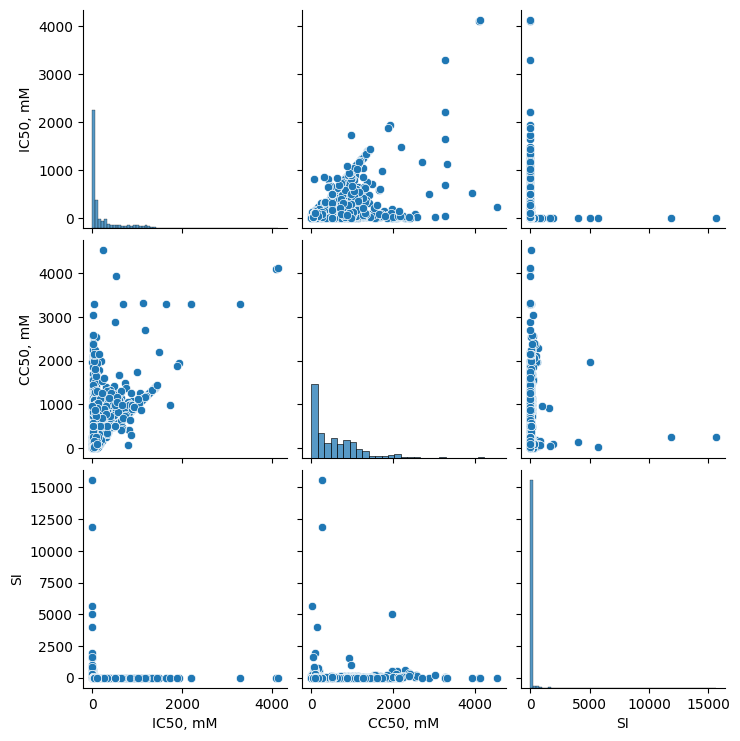

In [11]:
# Проверим связь между таргетами
sns.pairplot(df[['IC50, mM', 'CC50, mM', 'SI']])
plt.show()

- Между переменными IC50 и CC50 наблюдается слабая положительная зависимость.
- Переменная SI не демонстрирует линейной зависимости с IC50 и CC50, распределение точек сильно искажено и содержит большое количество выбросов.
Взаимосвязи между целевыми переменными носят нелинейный характер, что может усложнять задачу моделирования.

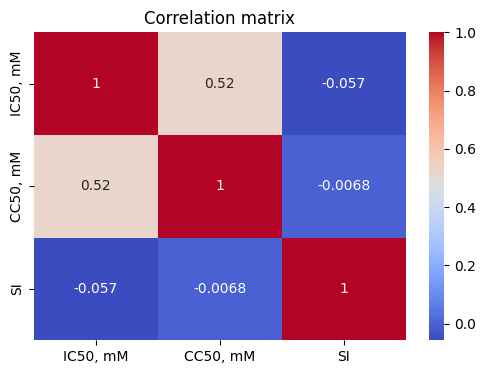

In [12]:
# Выведем матрицу корреляции целевых признаков
plt.figure(figsize=(6, 4))
sns.heatmap(df[['IC50, mM', 'CC50, mM', 'SI']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()

- Между IC50 и CC50 наблюдается умеренная положительная зависимость
- Переменная SI не демонстрирует линейной зависимости с IC50 и CC50
- Вероятно, зависимость SI носит нелинейный характер

In [13]:
# Проверка зависимости SI от IC50, mM и CC50, mM
df_check = df[['IC50, mM', 'CC50, mM', 'SI']].copy()

df_check['si_formula'] = df_check['CC50, mM'] / df_check['IC50, mM']
df_check['abs_diff'] = (df_check['SI'] - df_check['si_formula']).abs()
df_check['rel_diff'] = df_check['abs_diff'] / df_check['SI'].replace(0, np.nan)

df_check[['SI', 'si_formula', 'abs_diff', 'rel_diff']].describe()

,SI,si_formula,abs_diff,rel_diff
count,1001.000000,1001.000000,1.001000e+03,1.001000e+03
mean,72.508823,72.508823,9.032310e-15,1.502608e-16
std,684.482739,684.482739,9.159952e-14,1.651876e-16
min,0.011489,0.011489,0.000000e+00,0.000000e+00
25%,1.433333,1.433333,0.000000e+00,0.000000e+00
50%,3.846154,3.846154,4.440892e-16,1.370755e-16
75%,16.566667,16.566667,1.776357e-15,2.273737e-16
max,15620.600000,15620.600000,1.818989e-12,8.463040e-16


In [14]:
(df_check['abs_diff'] < 1e-10).mean()

np.float64(1.0)

In [15]:
df_check[['SI', 'si_formula']].corr()

,SI,si_formula
SI,1.0,1.0
si_formula,1.0,1.0


1. Все таргеты имеют сильную правую асимметрию. Логарифмирование оправдано
2. IC50 и CC50 умеренно коррелируют. Допустимо использовать по отдельности
3. SI полностью зависит от IC50 и CC50: SI = CC50 / IC50
    - нельзя одновременно использовать SI и (IC50, CC50)

#### Проверка датасета на наличие пропусков

In [16]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing_percent = round((missing / len(df)) * 100, 2)
missing_df = pd.DataFrame({
    'Кол-во пропусков': missing,
    'Процент пропусков': missing_percent
})
missing_df

,Кол-во пропусков,Процент пропусков
MinAbsPartialCharge,3,0.3
BCUT2D_LOGPHI,3,0.3
BCUT2D_MWHI,3,0.3
MaxAbsPartialCharge,3,0.3
MinPartialCharge,3,0.3
MaxPartialCharge,3,0.3
BCUT2D_MWLOW,3,0.3
BCUT2D_CHGHI,3,0.3
BCUT2D_CHGLO,3,0.3
BCUT2D_LOGPLOW,3,0.3


In [17]:
# Проверим сколько строк содержат пропуски
rows_with_missing = df[df.isnull().any(axis=1)]
rows_with_missing

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
78,78,1127.094988,1127.094988,1.000000,11.617504,11.617504,0.053210,-1.472941,0.344754,12.882353,...,0,0,0,0,0,0,0,0,0,0
79,79,25.171788,1878.491646,74.626866,11.617504,11.617504,0.053210,-1.472941,0.344754,12.882353,...,0,0,0,0,0,0,0,0,0,0
80,80,1199.174968,1199.174968,1.000000,11.600528,11.600528,0.228349,-0.861204,0.286242,10.937500,...,1,0,0,0,0,0,0,0,0,0


1) В датасете присутствуют пропуски в 12 признаках
2) Пропуски затрагивают только 3 строки (0.3% выборки)

Строки с пропусками необходимо удалить

#### Исследование признаков

In [18]:
targets = ['IC50, mM', 'CC50, mM', 'SI']
df_features = df.drop(columns=targets)

In [19]:
# ищем константные признаки
nunique = df_features.nunique()

constant_features = nunique[nunique == 1]
constant_features

NumRadicalElectrons    1
SMR_VSA8               1
SlogP_VSA9             1
fr_N_O                 1
fr_SH                  1
fr_azide               1
fr_barbitur            1
fr_benzodiazepine      1
fr_diazo               1
fr_dihydropyridine     1
fr_isocyan             1
fr_isothiocyan         1
fr_lactam              1
fr_nitroso             1
fr_phos_acid           1
fr_phos_ester          1
fr_prisulfonamd        1
fr_thiocyan            1
dtype: int64

Константные признаки бесполезны для построения моделей. Удалить их

#### Поиск признаков с низкой вариативностью

In [20]:
df_features.nunique().describe()

count     211.000000
mean      225.772512
std       305.941911
min         1.000000
25%         3.000000
50%        19.000000
75%       415.500000
max      1001.000000
dtype: float64

In [21]:
df_features.nunique().value_counts().sort_index().head(20)

1     18
2     30
3     14
4      6
5      8
6      6
7      3
8      6
9      5
10     3
11     1
12     1
13     1
14     1
15     2
19     1
21     3
22     1
29     1
30     1
Name: count, dtype: int64

In [22]:
binary_features = df_features.columns[df_features.nunique() == 2]
df_features[binary_features].sample(5)

,fr_Al_COO,fr_Ar_COO,fr_Ar_NH,fr_COO,fr_COO2,fr_C_S,fr_HOCCN,fr_Nhpyrrole,fr_aldehyde,fr_alkyl_carbamate,...,fr_oxazole,fr_priamide,fr_pyridine,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_urea
504,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
557,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
766,1,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
145,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
20,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [23]:
low_unique_features = df_features.columns[df_features.nunique().between(3, 5)]
df_features[low_unique_features].head()

,SMR_VSA2,EState_VSA11,NumAromaticCarbocycles,fr_ArN,fr_Imine,fr_NH1,fr_NH2,fr_Ndealkylation1,fr_Ndealkylation2,fr_amide,...,fr_ketone_Topliss,fr_lactone,fr_methoxy,fr_morpholine,fr_oxime,fr_para_hydroxylation,fr_piperdine,fr_piperzine,fr_quatN,fr_sulfide
0,0.0,0.0,0,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.0,0.0,0,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0.0,0.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,0
3,0.0,0.0,0,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0.0,0.0,2,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


- признаки с малым числом значений — нормальные
- информация в них есть
- удалять нельзя

#### Поиск выбросов в признаках

In [24]:
# Считаем выбросы через IQR
Q1 = df_features.quantile(0.25)
Q3 = df_features.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_count = ((df_features < lower_bound) | (df_features > upper_bound)).sum()

outliers_count.sort_values(ascending=False).head(20)

VSA_EState10             250
VSA_EState9              245
fr_amide                 243
fr_Al_OH                 243
fr_aniline               222
Ipc                      218
fr_allylic_oxid          209
PEOE_VSA4                205
fr_ester                 199
PEOE_VSA13               185
fr_Al_OH_noTert          182
PEOE_VSA5                166
fr_methoxy               154
fr_ketone                154
BCUT2D_MRHI              153
fr_para_hydroxylation    147
fr_aryl_methyl           144
SMR_VSA9                 141
fr_halogen               140
fr_Imine                 137
dtype: int64

In [25]:
outliers_percent = outliers_count / len(df_features) * 100
outliers_percent.sort_values(ascending=False).head(20)

VSA_EState10             24.975025
VSA_EState9              24.475524
fr_amide                 24.275724
fr_Al_OH                 24.275724
fr_aniline               22.177822
Ipc                      21.778222
fr_allylic_oxid          20.879121
PEOE_VSA4                20.479520
fr_ester                 19.880120
PEOE_VSA13               18.481518
fr_Al_OH_noTert          18.181818
PEOE_VSA5                16.583417
fr_methoxy               15.384615
fr_ketone                15.384615
BCUT2D_MRHI              15.284715
fr_para_hydroxylation    14.685315
fr_aryl_methyl           14.385614
SMR_VSA9                 14.085914
fr_halogen               13.986014
fr_Imine                 13.686314
dtype: float64

#### Проверка корреляций между признаками

In [26]:
corr_matrix = df_features.corr()
# Берем верхний треугольник
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [27]:
# Смотрим пары с высокой корреляцией:
high_corr = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notnull(upper.loc[row, col]) and abs(upper.loc[row, col]) > 0.9
]

len(high_corr)

154

In [28]:
high_corr[:10]

[('MaxEStateIndex', 'MaxAbsEStateIndex', np.float64(1.0)),
 ('HeavyAtomMolWt', 'MolWt', np.float64(0.9968500699143527)),
 ('ExactMolWt', 'MolWt', np.float64(0.9999985675531962)),
 ('ExactMolWt', 'HeavyAtomMolWt', np.float64(0.9968205134360122)),
 ('NumValenceElectrons', 'MolWt', np.float64(0.9812236854845559)),
 ('NumValenceElectrons', 'HeavyAtomMolWt', np.float64(0.96620144667007)),
 ('NumValenceElectrons', 'ExactMolWt', np.float64(0.9814357790361952)),
 ('MaxAbsPartialCharge', 'MinPartialCharge', np.float64(-0.9215002397470539)),
 ('MinAbsPartialCharge', 'MaxPartialCharge', np.float64(0.974736732493223)),
 ('FpDensityMorgan2', 'FpDensityMorgan1', np.float64(0.9477566410321767))]

Найдено 154 пары сильно коррелированных признака
Необходимо удалить часть признаков на основе корреляции

In [29]:
# создаём препроцессор и применяем к текущим данным
preprocessor = DatasetPreprocessor(
    target_column=None,
    drop_unnamed=True,
    drop_leakage=False,
    drop_constant_features=True,
    drop_corr=True,
    corr_threshold=0.9,
)

clean_df = df.dropna()
df_processed = preprocessor.fit_transform(clean_df)

print('Исходная форма:', df.shape)
print('После обработки:', df_processed.shape)
print('Удалено колонок:', df.shape[1] - df_processed.shape[1])

Исходная форма: (1001, 214)
После обработки: (998, 148)
Удалено колонок: 66


#### Анализ масштабов признаков

In [30]:
df_processed.describe().T[['min', 'max', 'std']].sort_values(by='std', ascending=False).head(20)

,min,max,std
Ipc,107.107191,3.951781e+13,1.257854e+12
SI,0.011489,1.562060e+04,6.855043e+02
"CC50, mM",0.700808,4.538976e+03,6.420165e+02
"IC50, mM",0.003517,4.128529e+03,4.005107e+02
MolWt,110.156000,9.047770e+02,1.270458e+02
TPSA,0.000000,4.075000e+02,4.569876e+01
SMR_VSA7,0.000000,1.329597e+02,3.175255e+01
SMR_VSA5,0.000000,1.743680e+02,2.957066e+01
SlogP_VSA5,0.000000,1.840771e+02,2.658824e+01
SlogP_VSA2,0.000000,2.131382e+02,2.376702e+01


In [31]:
df_processed.describe().T[['min', 'max', 'std']].sort_values(by='std').head(20)

,min,max,std
fr_Ar_COO,0.000000,1.000000,0.031654
fr_HOCCN,0.000000,1.000000,0.031654
fr_tetrazole,0.000000,1.000000,0.031654
fr_term_acetylene,0.000000,1.000000,0.031654
fr_aldehyde,0.000000,1.000000,0.054772
fr_hdrzine,0.000000,1.000000,0.054772
fr_oxazole,0.000000,1.000000,0.063214
fr_guanido,0.000000,1.000000,0.063214
MinPartialCharge,-0.744036,-0.085007,0.075974
fr_nitrile,0.000000,1.000000,0.077343


Признаки имеют разные масштабы значений. Использовать стандартизацию (StandardScaler) на этапе обучения

#### Анализ распределений признаков

In [32]:
targets = ['IC50, mM', 'CC50, mM', 'SI']
df_features_processed = df_processed.drop(columns=targets)

In [33]:
# считаем коэффициент асимметрии для каждого признака:
# положительное большое значение - длинный хвост вправо
# отрицательное большое по модулю значение - длинный хвост влево
# значение около 0 - распределение более симметричное
feature_skew = df_features_processed.skew()

# сортируем признаки по убыванию асимметрии,
# чтобы увидеть самые перекошенные вправо
feature_skew.sort_values(ascending=False).head(20).head(20)

fr_Ar_COO            31.591138
fr_tetrazole         31.591138
fr_HOCCN             31.591138
fr_term_acetylene    31.591138
Ipc                  31.083867
fr_piperzine         21.665056
fr_epoxide           18.712680
fr_hdrzine           18.184150
fr_aldehyde          18.184150
fr_guanido           15.724090
fr_oxazole           15.724090
fr_oxime             12.893944
fr_nitrile           12.799676
fr_azo               11.832125
fr_urea              11.832125
fr_amidine           11.051021
fr_sulfone           10.403038
SMR_VSA2              9.385214
fr_ArN                9.320908
fr_unbrch_alkane      9.214578
dtype: float64

In [34]:
# сортируем по возрастанию, чтобы увидеть самые перекошенные влево
df_features_processed.skew().sort_values().head(20)

BCUT2D_MWLOW        -14.159349
VSA_EState5          -2.734358
MinEStateIndex       -1.576585
MaxAbsEStateIndex    -0.964297
BCUT2D_CHGHI         -0.936415
qed                  -0.697268
BCUT2D_MRLOW         -0.689385
BCUT2D_LOGPHI        -0.557511
VSA_EState7          -0.526381
FpDensityMorgan1     -0.299900
MolLogP              -0.255922
MaxPartialCharge     -0.169014
FractionCSP3         -0.057417
AvgIpc                0.218113
SPS                   0.255133
BCUT2D_CHGLO          0.256217
MinPartialCharge      0.353339
SMR_VSA7              0.422257
VSA_EState4           0.461780
NumAliphaticRings     0.528118
dtype: float64

In [35]:
# берём только признаки, где больше 10 уникальных значений
numeric_features = df_features_processed.columns[
    df_features_processed.nunique() > 10
]

# считаем skew только для них
numeric_skew = df_features_processed[numeric_features].skew()

# смотрим самые перекошенные вправо
numeric_skew.sort_values(ascending=False).head(20)

Ipc                 31.083867
fr_unbrch_alkane     9.214578
VSA_EState3          4.356686
BCUT2D_MWHI          3.558333
EState_VSA5          3.461687
PEOE_VSA1            3.329752
PEOE_VSA10           3.173752
EState_VSA1          3.103912
NHOHCount            2.933040
PEOE_VSA3            2.903131
VSA_EState10         2.732589
PEOE_VSA5            2.681648
PEOE_VSA4            2.489117
SMR_VSA3             2.424012
PEOE_VSA11           2.406253
VSA_EState8          2.332194
BCUT2D_MRHI          2.289278
SMR_VSA9             2.281988
PEOE_VSA13           2.256878
TPSA                 2.192053
dtype: float64

In [36]:
# смотрим самые перекошенные влево
numeric_skew.sort_values().head(20)

BCUT2D_MWLOW        -14.159349
VSA_EState5          -2.734358
MinEStateIndex       -1.576585
MaxAbsEStateIndex    -0.964297
BCUT2D_CHGHI         -0.936415
qed                  -0.697268
BCUT2D_MRLOW         -0.689385
BCUT2D_LOGPHI        -0.557511
VSA_EState7          -0.526381
FpDensityMorgan1     -0.299900
MolLogP              -0.255922
MaxPartialCharge     -0.169014
FractionCSP3         -0.057417
AvgIpc                0.218113
SPS                   0.255133
BCUT2D_CHGLO          0.256217
MinPartialCharge      0.353339
SMR_VSA7              0.422257
VSA_EState4           0.461780
BalabanJ              0.553640
dtype: float64

array([[<Axes: title={'center': 'Ipc'}>,
        <Axes: title={'center': 'fr_unbrch_alkane'}>],
       [<Axes: title={'center': 'VSA_EState3'}>,
        <Axes: title={'center': 'BCUT2D_MWHI'}>],
       [<Axes: title={'center': 'EState_VSA5'}>, <Axes: >]], dtype=object)

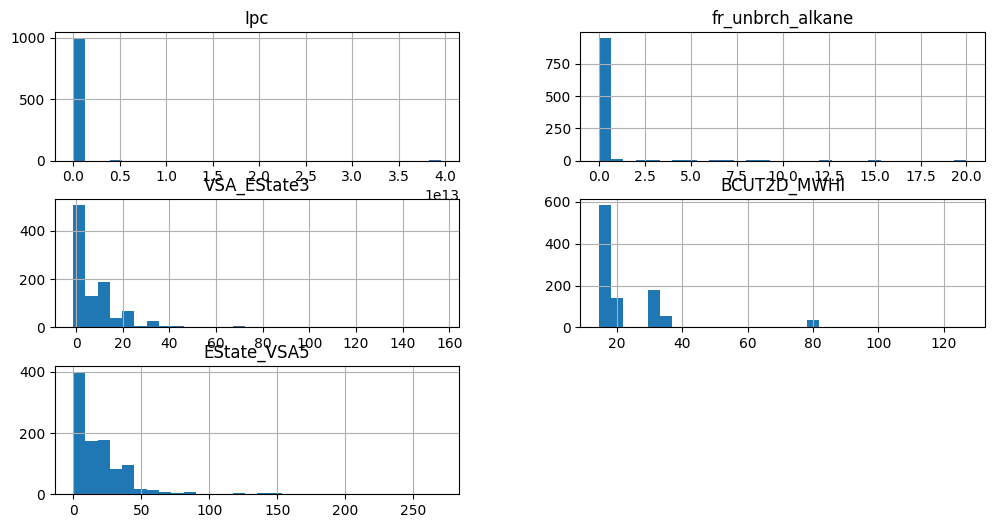

In [37]:
# проверим распределение 5 самых перекошенных вправо признаков
cols_to_check = numeric_skew.sort_values(ascending=False).head(5).index

df_features_processed[cols_to_check].hist(bins=30, figsize=(12, 6))

array([[<Axes: title={'center': 'BCUT2D_MWLOW'}>,
        <Axes: title={'center': 'VSA_EState5'}>],
       [<Axes: title={'center': 'MinEStateIndex'}>,
        <Axes: title={'center': 'MaxAbsEStateIndex'}>],
       [<Axes: title={'center': 'BCUT2D_CHGHI'}>, <Axes: >]], dtype=object)

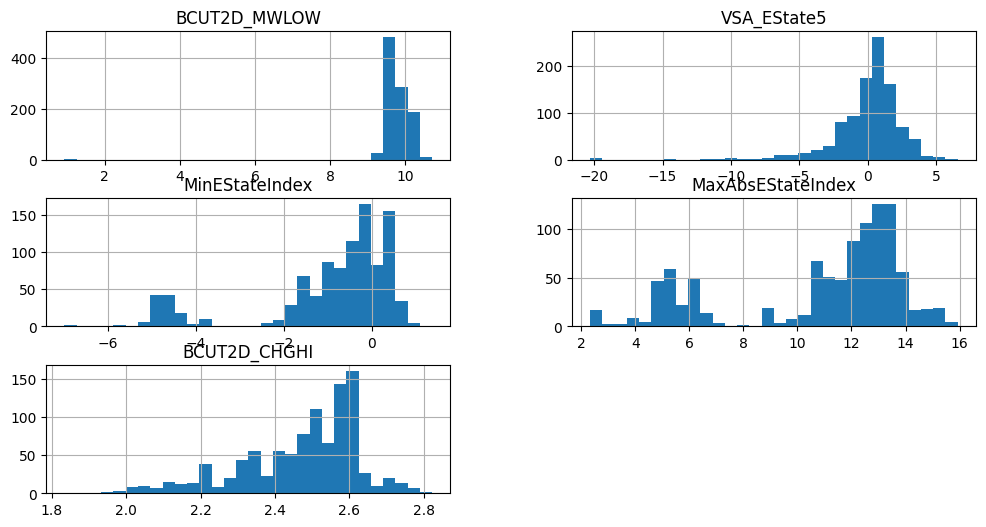

In [38]:
# проверим распределение 5 самых перекошенных влево признаков
cols_to_check = numeric_skew.sort_values().head(5).index

df_features_processed[cols_to_check].hist(bins=30, figsize=(12, 6))

In [40]:
# создаём препроцессор с полным набором подтверждённых правил
preprocessor = DatasetPreprocessor(
    target_column=None,            # общий EDA, не под конкретную задачу
    drop_unnamed=True,             # удалить служебный столбец
    drop_leakage=False,            # таргеты пока не убираем
    drop_constant_features=True,   # удалить константные признаки
    drop_corr=True,                # удалить сильно коррелированные признаки
    corr_threshold=0.9,            # порог сильной корреляции
    log_features=True,             # включить логарифмирование признаков
    log_skew_threshold=2.0,        # логарифмировать признаки с сильной правой асимметрией
    log_min_unique_values=10       # не трогать бинарные и почти дискретные признаки
)

# заново прогоняем ВЕСЬ исходный датасет через preprocessing
clean_df = df.dropna()
df_processed = preprocessor.fit_transform(clean_df)

# смотрим результат
print('Исходная форма:', df.shape)
print('После обработки:', df_processed.shape)
print('Удалено колонок:', df.shape[1] - df_processed.shape[1])

# смотрим, какие признаки были логарифмированы
print('Признаки, к которым применён log1p:')
print(preprocessor.log_features_)
print('Всего:', len(preprocessor.log_features_))

Исходная форма: (1001, 214)
После обработки: (998, 148)
Удалено колонок: 66
Признаки, к которым применён log1p:
['BCUT2D_MWHI', 'BCUT2D_MRHI', 'Ipc', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA13', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'SMR_VSA3', 'SMR_VSA6', 'SMR_VSA9', 'SlogP_VSA12', 'SlogP_VSA8', 'TPSA', 'EState_VSA1', 'EState_VSA5', 'VSA_EState10', 'NHOHCount', 'NumRotatableBonds', 'fr_NH0', 'fr_unbrch_alkane']
Всего: 23


Выявлены признаки с сильной правой асимметрией (skew > 2)
К таким признакам применено логарифмическое преобразование log1p

array([[<Axes: title={'center': 'BCUT2D_MWHI'}>,
        <Axes: title={'center': 'BCUT2D_MRHI'}>],
       [<Axes: title={'center': 'Ipc'}>,
        <Axes: title={'center': 'PEOE_VSA1'}>],
       [<Axes: title={'center': 'PEOE_VSA10'}>, <Axes: >]], dtype=object)

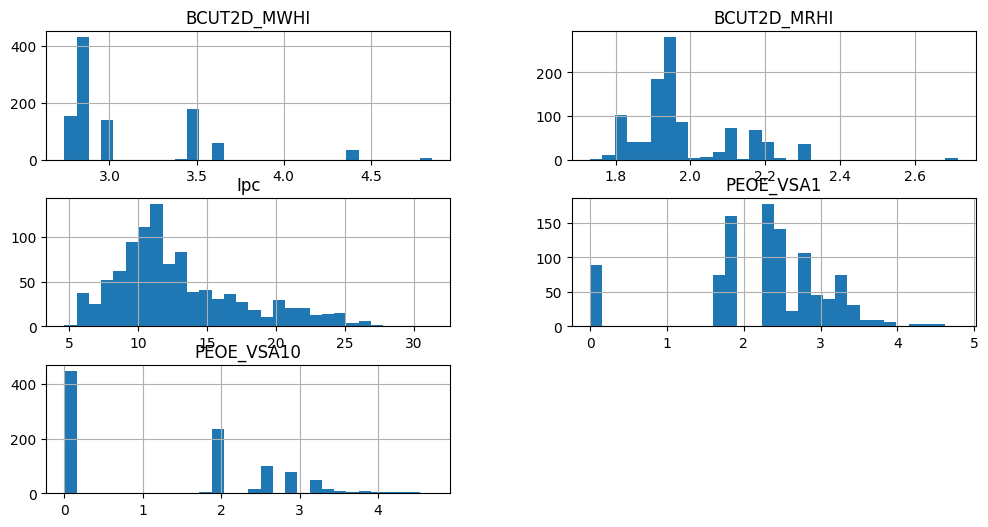

In [41]:
# смотрим распределение тех же признаков после логарифмирования
cols_to_check = preprocessor.log_features_[:5]
df_processed[cols_to_check].hist(bins=30, figsize=(12, 6))

log1p применён корректно. Есть полезный эффект:
- распределения стали менее скошенными
- влияние выбросов уменьшилось
